In [43]:
import numpy as np
import matplotlib.pyplot as plt

In [44]:
def linear_activation(x):
    return x

def adaline_predict(X,weights):
    Y = np.zeros(3)
    for i in range(Y.shape[0]):
        Y[i] = linear_activation(np.dot(X, weights[i, 1:]) + weights[i, 0])
    return Y

In [45]:
def adaline_train(X,y,learning_rate,n_epochs):
    weights = np.random.rand(y.shape[1],X.shape[1] + 1)
    errors = []
    for epoch in range(n_epochs):
        total_error = 0
        for xi, target in zip(X, y):
            output = adaline_predict(xi, weights)
            error = (target - output)**2
            total_error += np.sum(error)
            update = 2*learning_rate * (target - output)
            weights[:,1:] += np.outer(update, xi)
            weights[:,0] += update
        errors.append(total_error/X.shape[0])
    return weights,errors

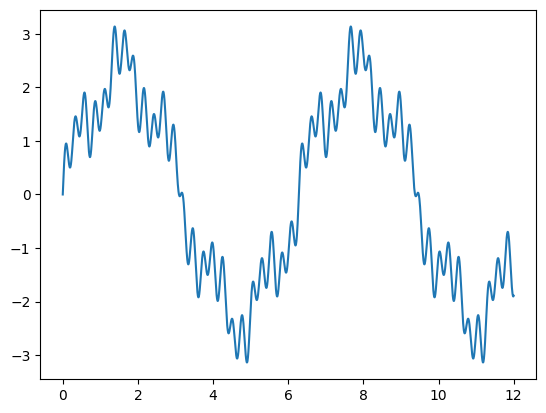

In [46]:
n_samples = 2000
t = np.linspace(0,12,n_samples)
A1 = 2.3
A2 = 0.5
A3 = 0.2
w1 = 1
w2 = 5
w3 = 15
x1 = A1*np.sin(w1*t)
x2 = A2*np.sin(w2*t)
x3 = A3*np.sin(w3*t)

noise = 0.4*np.sin(24*t)
X = x1+x2+x3 + noise

plt.plot(t,X)
plt.show()

In [47]:
delay = 55
y1 = x1[delay:]  
y2 = x2[delay:]
y3 = x3[delay:]

y = np.column_stack([y1,y2,y3])

noisy_signal = np.array([X[i:i+delay] for i in range(n_samples-delay)])

print(noisy_signal.shape)
d = y

print(d.shape)

weights,errors = adaline_train(noisy_signal, d, 0.0001, 1000)
print("Pesos entrenados: ", weights)
print("Errores: ", errors[-10:])

(1945, 55)
(1945, 3)
Pesos entrenados:  [[-0.11692815  0.16053236  0.06848056 -0.04967745 -0.08308095  0.0081805
   0.42808489 -0.31474539 -0.39349403 -0.25818167  0.48675073  0.1823834
   0.09539531  0.34535545  0.00517338 -0.60221978  0.30096906  0.08695796
   0.09554894 -0.12371696  0.00873605  0.27618844 -0.00549039 -0.68020933
   0.10735188 -0.11647954 -0.0229146   0.04748135 -0.22638086 -0.41184982
   0.49316087  0.17110096 -0.1339852   0.05931943  0.51445766  0.22941206
   0.32683415  0.30205341 -0.22099315 -0.29172899 -0.29957349  0.44959211
   0.03881286 -0.15152408 -0.17172809  0.17551387  0.22437798 -0.47866747
  -0.50274232 -0.4521756   0.32644465 -0.24131622  0.21919984  0.335367
   0.24850318  0.40508051]
 [ 0.08993355 -0.42070834 -0.3890459   0.13804337 -0.18710786 -0.0282326
   0.35408397  0.00519389 -0.23336806  0.53717567  0.22308115  0.16481708
  -0.07584001 -0.13698137  0.37156514 -0.39924248 -0.44004469  0.16594023
   0.13505748  0.14124834  0.06110862  0.18091578 

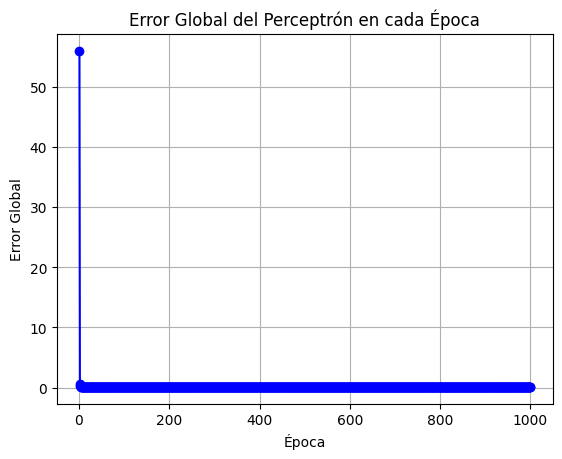

In [48]:
plt.figure()
plt.plot(range(1, len(errors) + 1), errors, marker='o', color='b')
plt.xlabel('Época')
plt.ylabel('Error Global')
plt.title('Error Global del Perceptrón en cada Época')
plt.grid(True)

tamaño de prediction después de llenado:  (1945, 3)


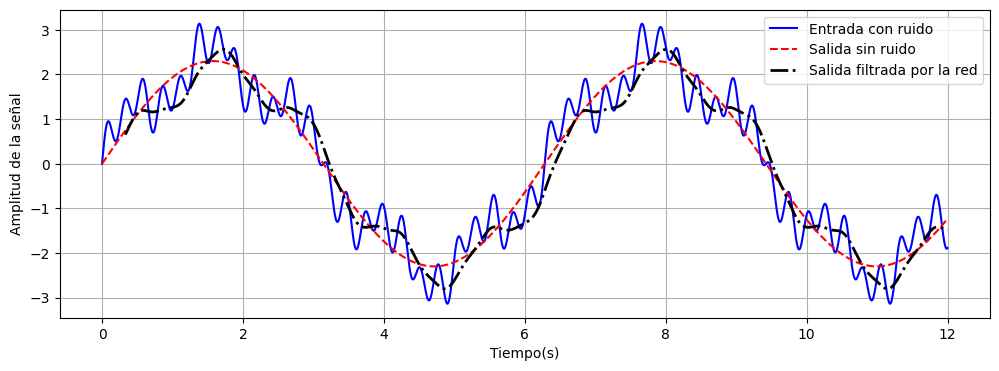

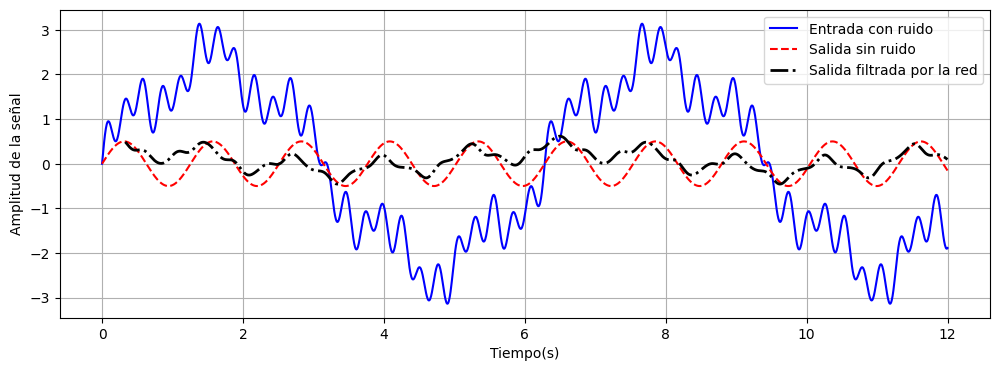

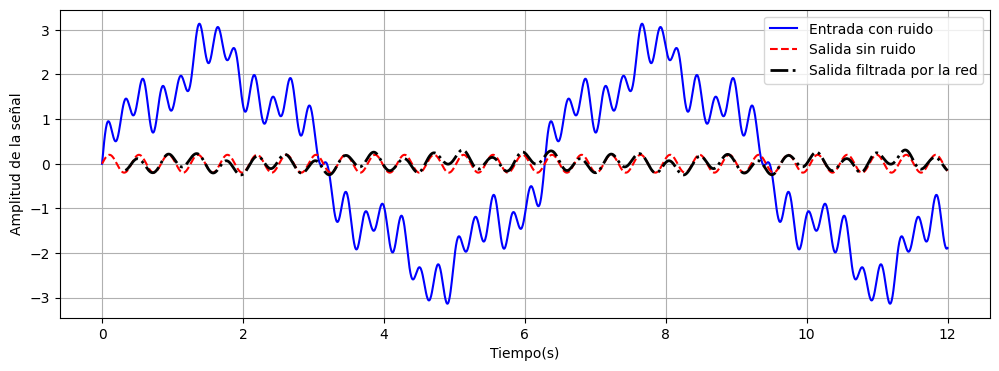

In [49]:
#señal filtrada

prediction = np.array([adaline_predict(xi, weights) for xi in noisy_signal])

print("tamaño de prediction después de llenado: ", prediction.shape)

plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(t,X,'b', label="Entrada con ruido")
plt.plot(t,x1,'--r', label="Salida sin ruido")
plt.plot(t[delay:],prediction[:,0],'-.k', linewidth=2, label='Salida filtrada por la red')
plt.legend()
plt.xlabel("Tiempo(s)")
plt.ylabel("Amplitud de la señal")
plt.show()

plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(t,X,'b', label="Entrada con ruido")
plt.plot(t,x2,'--r', label="Salida sin ruido")
plt.plot(t[delay:],prediction[:,1],'-.k', linewidth=2, label='Salida filtrada por la red')
plt.legend()
plt.xlabel("Tiempo(s)")
plt.ylabel("Amplitud de la señal")
plt.show()

plt.figure(figsize=(12,4))
plt.grid(True)
plt.plot(t,X,'b', label="Entrada con ruido")
plt.plot(t,x3,'--r', label="Salida sin ruido")
plt.plot(t[delay:],prediction[:,2],'-.k', linewidth=2, label='Salida filtrada por la red')
plt.legend()
plt.xlabel("Tiempo(s)")
plt.ylabel("Amplitud de la señal")
plt.show()
